**Problemas detectados:**

*1) Tabela Fato Vendas*

Valores numéricos com vírgula como separador decimal (ex: 2309,65) — em português isso é normal, mas em Python/pandas precisa trocar para ponto decimal.

Alguns valores têm precisão alta, como 3709,395 ou 5175,171 (3 casas decimais), pode ser normal, mas fique atenta.

Não está explícito se as colunas estão como texto ou numéricas (provável que estejam texto).

Não está claro o tipo dos dados (quantidade é int? custo envio float?).

Possível problema de integridade com o campo Pedido (chave primária?), porque nas dimensões Pedido há linhas repetidas para mesmo ID Pedido.

*2) Dimensão Cliente*

Não aparenta problemas graves.

IDs únicos, parece ok.

País, Estado, Cidade com acentos e letras maiúsculas — ok.

O que pode ser cuidado: tratar tipos de dados e remover espaços.

*3) Dimensão Produto*

Tem uma duplicação da mesma linha do produto TEC-AC-10003033 (repetida duas vezes exatamente igual).

Isso é um problema, porque dimensionais não devem ter duplicatas para o mesmo ID Produto.

É necessário remover duplicatas.

*4) Dimensão Pedido*

Apresenta IDs Pedido repetidos (exemplo: CA-2012-124891 aparece duas vezes exatamente iguais).

Isso pode causar problemas na modelagem estrela, já que dimensão deve ter IDs únicos.

O ideal: manter somente uma linha por pedido.

Datas estão no formato brasileiro dd/mm/yyyy — precisa converter para datetime.

Colunas modo envio e prioridade são categóricas.

**Objetivo:**
Corrigir os tipos de dados;

Remover duplicatas nas dimensões (Produto, Pedido);

Ajustar decimais na tabela fato;

Converter datas;

Garantir integridade para modelagem star schema.

# Nova secção

In [ ]:
import numpy as np
import pandas as pd

vendas_df=pd.read_csv('/content/sample_data/Vendas.csv', sep=';', decimal=',')
clientes_df=pd.read_csv('/content/sample_data/Clientes.csv', sep=';')
produtos_df=pd.read_csv('/content/sample_data/Produtos.csv', sep=';')
pedidos_df=pd.read_csv('/content/sample_data/Pedidos.csv', sep=';')

In [ ]:
import os # Import the os module

# Verificar os arquivos para garantir
print(os.listdir('/content/sample_data/')) # Specify the directory to list


['anscombe.json', 'README.md', 'Clientes.csv', 'Produtos.csv', 'Pedidos.csv', 'Vendas.csv', 'mnist_test.csv', 'california_housing_test.csv', 'california_housing_train.csv', 'mnist_train_small.csv']


In [ ]:
vendas_df.head(10)


,Pedido,Cliente,Produto,Valor Venda,Quantidade Vendida,Custo Envio
0,CA-2012-124891,RH-19495,TEC-AC-10003033,2309.650,7,933.57
1,IN-2013-77878,JR-16210,FUR-CH-10003950,3709.395,9,923.63
2,IN-2013-71249,CR-12730,TEC-PH-10004664,5175.171,9,915.49
3,ES-2013-1579342,KM-16375,TEC-PH-10004583,2892.510,5,910.16
4,SG-2013-4320,RH-9495,TEC-SHA-10000501,2832.960,8,903.04
5,IN-2013-42360,JM-15655,TEC-PH-10000030,2862.675,5,897.35
6,IN-2011-81826,TS-21340,FUR-CH-10004050,1822.080,4,894.77
7,IN-2012-86369,MB-18085,FUR-TA-10002958,5244.840,6,878.38
8,CA-2014-135909,JW-15220,OFF-BI-10003527,5083.960,5,867.69
9,CA-2012-116638,JH-15985,FUR-TA-10000198,4297.644,13,865.74


In [ ]:
clientes_df.head(10)

,ID Cliente,Nome Cliente,Segmento,Cidade,Estado,Pais,Mercado,Regiao
0,RH-19495,Rick Hansen,Consumidor,New York City,New York,United States,US,East
1,JR-16210,Justin Ritter,Corporativo,Wollongong,New South Wales,Australia,APAC,Oceania
2,CR-12730,Craig Reiter,Consumidor,Brisbane,Queensland,Australia,APAC,Oceania
3,KM-16375,Katherine Murray,Outros,Berlin,Berlin,Germany,EU,Central
4,RH-9495,Rick Hansen,Consumidor,Dakar,Dakar,Senegal,Africa,Africa
5,JM-15655,Jim Mitchum,Corporativo,Sydney,New South Wales,Australia,APAC,Oceania
6,TS-21340,Toby Swindell,Consumidor,Porirua,Wellington,New Zealand,APAC,Oceania
7,MB-18085,Mick Brown,Consumidor,Hamilton,Waikato,New Zealand,APAC,Oceania
8,JW-15220,Jane Waco,Corporativo,Sacramento,California,United States,US,West
9,JH-15985,Joseph Holt,Consumidor,Concord,North Carolina,United States,US,South


In [ ]:
produtos_df.head(10)

,ID Produto,Categoria,SubCategoria,Nome Produto
0,TEC-AC-10003033,Tecnologia,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...
1,TEC-AC-10003033,Tecnologia,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...
2,FUR-CH-10003950,Moveis,Chairs,"Novimex Executive Leather Armchair, Black"
3,TEC-PH-10004664,Tecnologia,Phones,"Nokia Smart Phone, with Caller ID"
4,TEC-PH-10004583,Tecnologia,Phones,"Motorola Smart Phone, Cordless"
5,TEC-SHA-10000501,Tecnologia,Copiers,"Sharp Wireless Fax, High-Speed"
6,TEC-PH-10000030,Tecnologia,Phones,"Samsung Smart Phone, with Caller ID"
7,FUR-CH-10004050,Moveis,Chairs,"Novimex Executive Leather Armchair, Adjustable"
8,FUR-TA-10002958,Moveis,Tables,"Chromcraft Conference Table, Fully Assembled"
9,OFF-BI-10003527,Material de Escritorio,Binders,Fellowes PB500 Electric Punch Plastic Comb Bin...


In [ ]:
pedidos_df.head(10)

,ID Pedido,Data Pedido,Data Envio,Modo Envio,Prioridade Pedido
0,CA-2012-124891,31-07-2012,31-07-2012,Mesmo Dia,Critico
1,CA-2012-124891,31-07-2012,31-07-2012,Mesmo Dia,Critico
2,IN-2013-77878,05-02-2013,07-02-2013,Segunda Classe,Critico
3,IN-2013-71249,17-10-2013,18-10-2013,Primeira Classe,Medio
4,ES-2013-1579342,28-01-2013,30-01-2013,Primeira Classe,Medio
5,SG-2013-4320,05-11-2013,06-11-2013,Mesmo Dia,Critico
6,IN-2013-42360,28-06-2013,01-07-2013,Segunda Classe,Critico
7,IN-2011-81826,07-11-2011,09-11-2011,Primeira Classe,Critico
8,IN-2012-86369,14-04-2012,18-04-2012,Classe Padrao,Alto
9,CA-2014-135909,14-10-2014,21-10-2014,Classe Padrao,Baixo


In [ ]:
# Now apply the corrections below:
def corrigir_fatos(df):
    df['Valor Venda'] = df['Valor Venda'].astype(str).str.replace(',', '.').astype(float)
    df['Custo Envio'] = df['Custo Envio'].astype(str).str.replace(',', '.').astype(float)
    df['Quantidade Vendida'] = df['Quantidade Vendida'].astype(int)
    return df

In [ ]:
vendas_df.head(10)

,Pedido,Cliente,Produto,Valor Venda,Quantidade Vendida,Custo Envio
0,CA-2012-124891,RH-19495,TEC-AC-10003033,2309.650,7,933.57
1,IN-2013-77878,JR-16210,FUR-CH-10003950,3709.395,9,923.63
2,IN-2013-71249,CR-12730,TEC-PH-10004664,5175.171,9,915.49
3,ES-2013-1579342,KM-16375,TEC-PH-10004583,2892.510,5,910.16
4,SG-2013-4320,RH-9495,TEC-SHA-10000501,2832.960,8,903.04
5,IN-2013-42360,JM-15655,TEC-PH-10000030,2862.675,5,897.35
6,IN-2011-81826,TS-21340,FUR-CH-10004050,1822.080,4,894.77
7,IN-2012-86369,MB-18085,FUR-TA-10002958,5244.840,6,878.38
8,CA-2014-135909,JW-15220,OFF-BI-10003527,5083.960,5,867.69
9,CA-2012-116638,JH-15985,FUR-TA-10000198,4297.644,13,865.74


In [ ]:
vendas_df.dtypes

,0
Pedido,object
Cliente,object
Produto,object
Valor Venda,float64
Quantidade Vendida,int64
Custo Envio,float64


In [ ]:
vendas_df[['Valor Venda', 'Custo Envio', 'Quantidade Vendida']].describe()

,Valor Venda,Custo Envio,Quantidade Vendida
count,51290.000000,51290.000000,51290.000000
mean,246.490581,26.375915,3.476545
std,487.565361,57.296804,2.278766
min,0.444000,0.000000,1.000000
25%,30.758625,2.610000,2.000000
50%,85.053000,7.790000,3.000000
75%,251.053200,24.450000,5.000000
max,22638.480000,933.570000,14.000000


In [ ]:
def corrigir_dim_produto(df):
    df = df.drop_duplicates(subset='ID Produto')
    return df

In [ ]:
def corrigir_dim_pedido(df):
    df = df.drop_duplicates(subset='ID Pedido')
    df['Data Pedido'] = pd.to_datetime(df['Data Pedido'], dayfirst=True)
    df['Data Envio'] = pd.to_datetime(df['Data Envio'], dayfirst=True)
    return df

In [ ]:
def corrigir_dim_cliente(df):
    str_cols = ['ID Cliente', 'Nome Cliente', 'Segmento', 'Cidade', 'Estado', 'Pais', 'Mercado', 'Regiao']
    for col in str_cols:
        df[col] = df[col].astype(str).str.strip()
    return df

In [ ]:
# Apply corrections
venda_df = corrigir_fatos(vendas_df)
produto_df = corrigir_dim_produto(produtos_df)
pedido_df = corrigir_dim_pedido(pedidos_df)
cliente_df = corrigir_dim_cliente(clientes_df)

/tmp/ipython-input-3968580298.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Data Pedido'] = pd.to_datetime(df['Data Pedido'], dayfirst=True)
/tmp/ipython-input-3968580298.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Data Envio'] = pd.to_datetime(df['Data Envio'], dayfirst=True)


In [ ]:
# Check integrity
def verificar_integridade(fato, cliente, produto, pedido):
    erros_cliente = fato[~fato['Cliente'].isin(cliente['ID Cliente'])]
    erros_produto = fato[~fato['Produto'].isin(produto['ID Produto'])]
    erros_pedido = fato[~fato['Pedido'].isin(pedido['ID Pedido'])]

    print(f'Clientes não encontrados na dimensão: {erros_cliente["Cliente"].unique()}')
    print(f'Produtos não encontrados na dimensão: {erros_produto["Produto"].unique()}')
    print(f'Pedidos não encontrados na dimensão: {erros_pedido["Pedido"].unique()}')

In [ ]:
verificar_integridade(venda_df, cliente_df, produto_df, pedido_df)

Clientes não encontrados na dimensão: []
Produtos não encontrados na dimensão: []
Pedidos não encontrados na dimensão: []


In [ ]:
import pandas as pd

Pergunta 1: "Qual é o valor médio de venda por pedido? Existe muita variação entre pedidos?"

Métrica: Média (mean) e Desvio-padrão (std).

In [ ]:
venda_df.groupby("Pedido")["Valor Venda"].sum().agg(['min','max','mean','std','median'])


,Valor Venda
min,0.556000
max,23661.228000
mean,504.993086
std,807.070936
median,206.820000


Pergunta 2: "Qual é a quantidade média e mediana vendida por produto? Existe algum produto com vendas muito discrepantes?"

Métrica: Média (mean) vs Mediana (median) (sensível a outliers).

In [ ]:
venda_df.groupby("Produto")["Quantidade Vendida"].agg(['sum','mean','median']).sort_values("sum", ascending=False)


,sum,mean,median
Produto,,,
OFF-AR-10003651,163,4.657143,4.0
OFF-BI-10002799,130,4.333333,3.0
OFF-AR-10003829,117,3.774194,3.0
OFF-BI-10001808,112,4.666667,4.0
OFF-BI-10003708,111,3.700000,3.0
...,...,...,...
TEC-SHA-10001976,1,1.000000,1.0
OFF-PA-10001448,1,1.000000,1.0
FUR-ADV-10002329,1,1.000000,1.0


Pergunta 3: "Qual é o tempo médio e mediano de entrega dos pedidos? E qual o pedido mais rápido e mais demorado?"

Métrica: Média, Mediana, Mínimo (min), Máximo (max).

In [ ]:
# Apply corrections to pedido_df again to ensure date columns are datetime objects
pedido_df = corrigir_dim_pedido(pedido_df)

pedido_df["LeadTime"] = (pedido_df["Data Envio"] - pedido_df["Data Pedido"]).dt.days
pedido_df["LeadTime"].agg(['mean','median','min','max'])

,LeadTime
mean,3.961174
median,4.000000
min,0.000000
max,7.000000


Pergunta 4: "A receita está distribuída igualmente entre os clientes ou concentrada em poucos? Qual o coeficiente de assimetria da receita por cliente?"

Métrica: Assimetria (skew).

In [ ]:
import scipy.stats as stats
receita_clientes = venda_df.groupby("Cliente")["Valor Venda"].sum()
print("Assimetria:", stats.skew(receita_clientes))


Assimetria: 0.7555502004752104


Pergunta 5: "Qual é a variabilidade (variância e desvio-padrão) do custo de envio? Há pedidos com custo muito fora do normal?"

Métrica: Variância (var) e Desvio-padrão (std).

In [ ]:
venda_df["Custo Envio"].agg(['var','std','min','max','median','mean'])


,Custo Envio
var,3282.923736
std,57.296804
min,0.000000
max,933.570000
median,7.790000
mean,26.375915


Pergunta 6: "Quais pedidos são outliers no valor total de venda?" Quais pedidos tiveram o custo fora do normal?

Métrica: Quartis (quantile), Intervalo Interquartil (IQR).

In [ ]:
pedido_total = venda_df.groupby("Pedido")["Valor Venda"].sum()
Q1, Q3 = pedido_total.quantile([0.25, 0.75])
IQR = Q3 - Q1
outliers = pedido_total[(pedido_total < Q1 - 1.5*IQR) | (pedido_total > Q3 + 1.5*IQR)]
print(outliers)


Pedido
AG-2011-4560    1475.97
AG-2011-9670    1589.40
AG-2012-2200    1447.44
AG-2012-2220    1996.11
AG-2012-4630    2366.10
                 ...   
ZA-2011-8980    2881.08
ZA-2012-2040    1828.26
ZA-2013-8130    2696.85
ZA-2013-9800    2004.00
ZA-2014-7540    2310.21
Name: Valor Venda, Length: 2176, dtype: float64


Pergunta 7: Qual é o ticket médio por região?

Conecta: KPI de ticket médio + segmentação geográfica.

Habilidade: groupby + mean.

Discussão: como regiões mais ricas ou mais populosas podem impactar o valor médio das compras.

Regiao
Central Asia      291.192259
West              270.346429
Southeast Asia    269.161079
East              268.589018
North Asia        268.122864
Central           264.220148
Oceania           263.983155
South             261.133117
Caribbean         260.365642
North             255.533491
Africa            173.441383
EMEA              159.278218
Canada            157.317173
Name: Valor Venda, dtype: float64


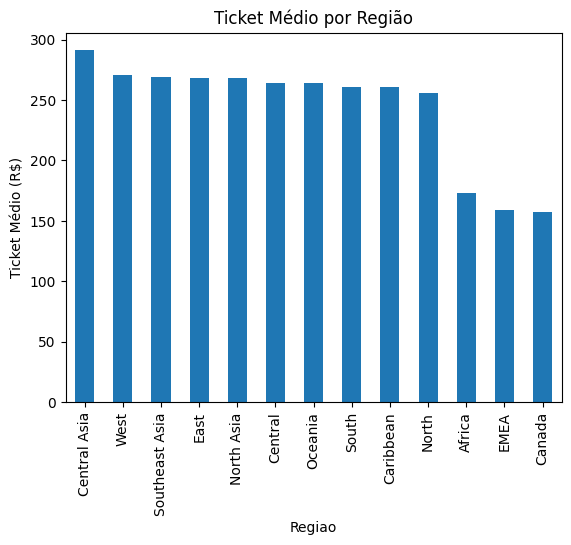

In [ ]:
# Ticket médio = Faturamento / Número de pedidos
# Merge region information from cliente_df
vendas_df_with_region = vendas_df.merge(cliente_df[['ID Cliente', 'Regiao']], left_on='Cliente', right_on='ID Cliente', how='left')

ticket_regiao = vendas_df_with_region.groupby("Regiao")["Valor Venda"].mean().reset_index()

ticket_regiao = vendas_df_with_region.groupby("Regiao")["Valor Venda"].mean().sort_values(ascending=False)



print(ticket_regiao)

# Visualização
import matplotlib.pyplot as plt

ticket_regiao.plot(x="Regiao", y="Valor Venda", kind="bar", legend=False)
plt.ylabel("Ticket Médio (R$)")
plt.title("Ticket Médio por Região")
plt.show()

Pergunta 8: Quais produtos apresentam maior taxa de devolução?

Conecta: análise de qualidade de produto e impacto no cliente.

Habilidade: cálculo de proporção (pedidos devolvidos / pedidos totais).

Discussão: influência de devoluções na margem de lucro.

In [ ]:
# Proporção de devoluções = Pedidos devolvidos / Pedidos totais
devolucao_produto = df.groupby("Product")["Returned"].mean().reset_index()
devolucao_produto = devolucao_produto.sort_values("Returned", ascending=False)

print(devolucao_produto.head(10))


**deve ocorrer um erro!!!**
esse erro aconteceu porque no seu ambiente não existe o objeto df — você carregou as tabelas em vendas_df, produto_df, cliente_df, pedido_df, mas não fez a junção delas em um único DataFrame.
precisamos trabalhar a modelagem do star schema



**ALÉM DISSO: NÃO TEM O CAMPO "DEVOLUÇÃO"**

Se o seu escopo de 4 tabelas não contempla devoluções, troque a pergunta de negócio para algo medível com os dados atuais, por exemplo:

“Quais produtos têm maior custo médio de envio?”

“Quais produtos têm maior variabilidade (desvio‑padrão) de quantidade vendida?”

“Quais produtos têm maior lead time médio de entrega?”

Pergunta 9: Existe relação entre desconto aplicado e aumento no volume de vendas?

Conecta: análise de elasticidade de preço.

Habilidade: correlation, scatter plot.

Discussão: descontos realmente aumentam o faturamento ou apenas reduzem a margem?

Pergunta 10: Quem são os Top 10 clientes em termos de faturamento acumulado?

Conecta: análise de Pareto (80/20).

Habilidade: groupby cliente + sum vendas.

Discussão: dependência de grandes clientes para a receita.

In [ ]:
# 1) Calcular faturamento acumulado por cliente
top_clientes = (
    venda_df.groupby("Cliente")["Valor Venda"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_clientes)


Cliente
TA-21385    35668.12080
GT-14710    34471.89028
TC-20980    34218.26900
SM-20320    31125.29496
BW-11110    30613.61650
HL-15040    29664.23058
SE-20110    29532.62502
PS-19045    29252.31940
RB-19360    29197.63460
ZC-21910    28472.81926
Name: Valor Venda, dtype: float64


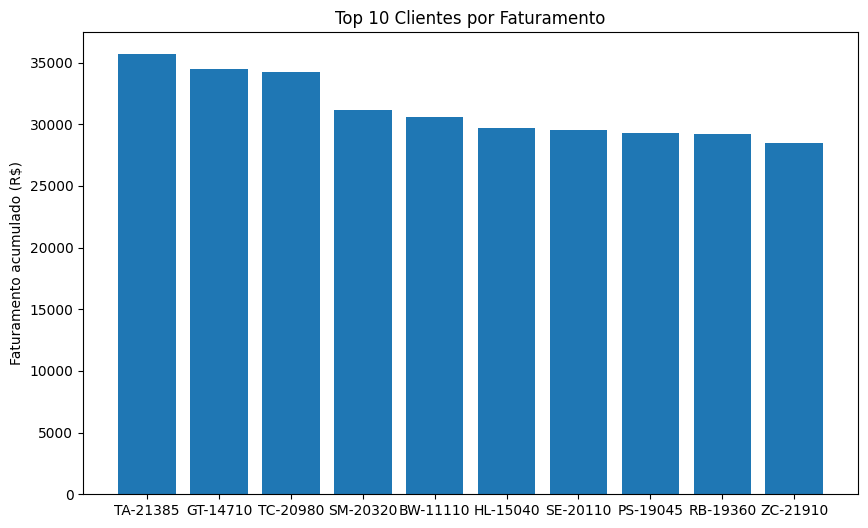

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.bar(top_clientes.index, top_clientes.values)
plt.title("Top 10 Clientes por Faturamento")
plt.ylabel("Faturamento acumulado (R$)")
plt.show()


In [ ]:
# Top 10 clientes por faturamento
top_clientes = (
    venda_df.groupby("Cliente", as_index=False)["Valor Venda"]
      .sum()
      .rename(columns={"Valor Venda": "Faturamento"})
      .sort_values("Faturamento", ascending=False)
      .head(10)
)

# Calcular participação percentual no total
total_faturamento = venda_df["Valor Venda"].sum()
top_clientes["% do Total"] = (top_clientes["Faturamento"] / total_faturamento * 100).round(2)

print(top_clientes)

# Ver também o acumulado (cumulative sum) -> ajuda a mostrar Pareto
top_clientes["% Acumulado"] = top_clientes["% do Total"].cumsum()
print(top_clientes)


       Cliente  Faturamento  % do Total
1463  TA-21385  35668.12080        0.28
623   GT-14710  34471.89028        0.27
1489  TC-20980  34218.26900        0.27
1405  SM-20320  31125.29496        0.25
237   BW-11110  30613.61650        0.24
656   HL-15040  29664.23058        0.23
1369  SE-20110  29532.62502        0.23
1220  PS-19045  29252.31940        0.23
1243  RB-19360  29197.63460        0.23
1587  ZC-21910  28472.81926        0.23
       Cliente  Faturamento  % do Total  % Acumulado
1463  TA-21385  35668.12080        0.28         0.28
623   GT-14710  34471.89028        0.27         0.55
1489  TC-20980  34218.26900        0.27         0.82
1405  SM-20320  31125.29496        0.25         1.07
237   BW-11110  30613.61650        0.24         1.31
656   HL-15040  29664.23058        0.23         1.54
1369  SE-20110  29532.62502        0.23         1.77
1220  PS-19045  29252.31940        0.23         2.00
1243  RB-19360  29197.63460        0.23         2.23
1587  ZC-21910  28472.81926   

**O Princípio de Pareto (Regra 80/20)**

O Princípio de Pareto, também conhecido como Regra 80/20, é um conceito clássico em análise de negócios, qualidade e estatística. Ele foi desenvolvido pelo economista italiano Vilfredo Pareto, que observou no final do século XIX que cerca de 80% das terras na Itália pertenciam a apenas 20% da população.

Com o tempo, esse padrão foi identificado em diversos contextos — mostrando que uma pequena parte das causas gera a maior parte dos efeitos.



KeyError: 'Nome Cliente'

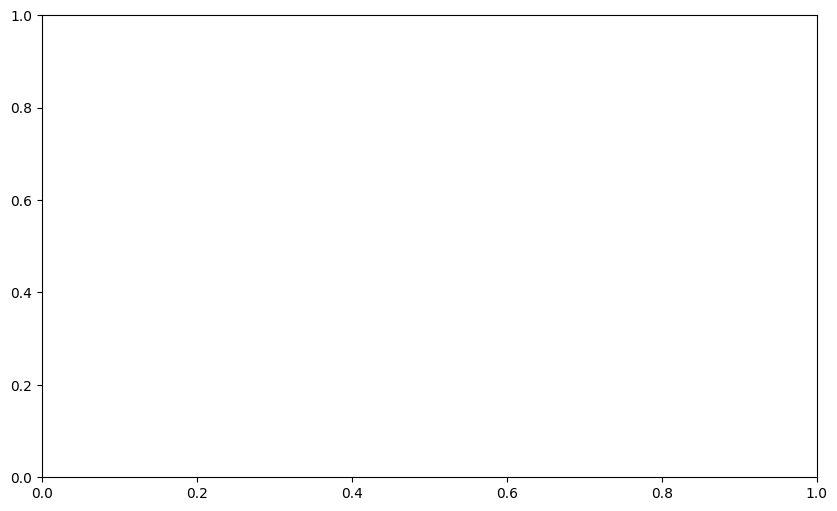

In [ ]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10,6))

# Barras para faturamento
ax1.bar(top_clientes["Nome Cliente"], top_clientes["Faturamento"], color="darkblue")
ax1.set_ylabel("Faturamento (R$)", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")
ax1.set_xticklabels(top_clientes["Nome Cliente"], rotation=45, ha="right")

# Linha para % acumulado
ax2 = ax1.twinx()
ax2.plot(top_clientes["Nome Cliente"], top_clientes["% Acumulado"], color="red", marker="o")
ax2.set_ylabel("% Acumulado", color="red")
ax2.tick_params(axis="y", labelcolor="red")
ax2.axhline(80, color="green", linestyle="--", label="Linha de Pareto (80%)")
ax2.legend(loc="lower right")

plt.title("Top 10 Clientes - Faturamento e Pareto")
plt.show()


Pergunta 11: Qual é o tempo médio entre o pedido e a entrega? Esse tempo varia por região?

Conecta: logística, supply chain e impacto na satisfação do cliente.

Habilidade: manipulação de datas, timedelta, médias por grupos.

Discussão: como atrasos em regiões específicas podem prejudicar a percepção da marca.

In [ ]:
# Criar coluna de LeadTime (em dias)
pedido_df["LeadTime"] = (pedido_df["Data Envio"] - pedido_df["Data Pedido"]).dt.days

# Estatísticas gerais
leadtime_stats = pedido_df["LeadTime"].agg(['mean', 'median', 'min', 'max']).round(2)
print("Tempo médio (dias):", leadtime_stats['mean'])
print("Tempo mediano (dias):", leadtime_stats['median'])
print("Mais rápido (dias):", leadtime_stats['min'])
print("Mais demorado (dias):", leadtime_stats['max'])


In [ ]:
# Juntar pedido_df (com LeadTime) e cliente_df (com Região)
pedido_cliente = pedido_df.merge(cliente_df[['ID Cliente', 'Regiao']],
                                 left_on="ID Pedido", right_on="ID Cliente", how="left")

# Agrupar por Região
leadtime_regiao = pedido_cliente.groupby("Regiao")["LeadTime"].agg(['mean','median','min','max']).round(2)

print(leadtime_regiao)






#Merge das Tabelas
df_vendas_grouped.merge(produto_df[["ID Produto", "Nome Produto"]], left_on="Produto", right_on="ID Produto", how="left")[["Produto", "Preco_medio", "Categoria_Preco", "Nome Produto"]]

#Agrupamento dos Produtos
df_vendas_grouped = vendas_df.groupby("Produto", as_index=False).sum()

df_vendas_grouped["Preco_medio"] = round(df_vendas_grouped["Valor Venda"] / df_vendas_grouped["Quantidade Vendida"],2)

df_vendas_grouped["Categoria_Preco"] = df_vendas_grouped["Preco_medio"].apply(
    lambda x: 'Barato' if x < 50 else ('Médio' if x < 200 else 'Caro')
)

display(df_vendas_grouped[["Produto", "Preco_medio", "Categoria_Preco"]].sort_values(by="Categoria_Preco").head(20))




Pergunta 12:
A diretoria gostaria de uma categorização simples dos produtos com base no preço unitário:

Produtos "Baratos" → preço < 50

Produtos "Médios" → 50 ≤ preço < 200

Produtos "Caros" → preço ≥ 200

Crie uma nova coluna chamada Categoria_Preco na tabela de produtos utilizando lambda functions para classificar cada produto.

In [ ]:
import pandas as pd

# Exemplo: tabela de produtos
df_produtos = pd.DataFrame({
    'ProdutoID': [1, 2, 3, 4, 5],
    'NomeProduto': ['Caderno', 'Notebook', 'Caneta', 'Monitor', 'Teclado'],
    'PrecoUnitario': [25, 3500, 5, 900, 150]
})

# Criando a coluna usando lambda
df_produtos['Categoria_Preco'] = df_produtos['PrecoUnitario'].apply(
    lambda x: 'Barato' if x < 50 else ('Médio' if x < 200 else 'Caro')
)

print(df_produtos)


Pergunta 13 — Classificar faixas de valor do pedido com lambda e analisar receita por região

Enunciado:
Classifique cada pedido em Baixo (< 500), Médio (≥ 500 e < 2.000) ou Alto (≥ 2.000) com base no valor total do pedido. Depois, calcule a participação da receita por região dentro de cada faixa.

Código (pressupõe df_star já com Fato + Dimensões e colunas Pedido, Valor Venda, Regiao):

In [ ]:
import pandas as pd
import pandas as pd

# 1) Trazer a Região da dimensão de clientes para a fato
vendas_base = (
    vendas_df.merge(
        cliente_df[["ID Cliente", "Regiao"]],
        left_on="Cliente", right_on="ID Cliente",
        how="left"
    )
)

# 2) Garantir que 'Valor Venda' é numérico (caso tenha vindo como texto)
if vendas_base["Valor Venda"].dtype == "object":
    vendas_base["Valor Venda"] = (
        vendas_base["Valor Venda"].astype(str)
                                   .str.replace(",", ".", regex=False)
                                   .astype(float)
    )

# 3) Criar a faixa de valor com lambda
vendas_base["FaixaValor"] = vendas_base["Valor Venda"].apply(
    lambda x: "Baixo" if x < 500 else ("Médio" if x < 2000 else "Alto")
)

# 4) Receita por Região + Faixa
receita_faixa_regiao = (
    vendas_base
    .groupby(["FaixaValor", "Regiao"], dropna=False)["Valor Venda"]
    .sum()
    .reset_index()
)

# 5) Participação da região dentro de cada faixa (%)
receita_faixa_regiao["Participacao"] = (
    receita_faixa_regiao.groupby("FaixaValor")["Valor Venda"]
                        .transform(lambda s: s / s.sum() * 100)
).round(2)

# 6) Resultado ordenado (dentro de cada faixa, do maior % para o menor)
resultado = receita_faixa_regiao.sort_values(
    ["FaixaValor", "Participacao"], ascending=[True, False]
)

print(resultado.head(30))  # ajuste a quantidade conforme quiser


Pergunta 14 — Marcar Cliente VIP com lambda via percentil e medir impacto na receita

Enunciado:
Considere VIP os clientes cujo faturamento acumulado esteja no percentil 90 (top 10%). Marque-os com lambda e calcule a participação dos VIPs na receita total.

Código (pressupõe colunas Cliente, Valor Venda):

In [ ]:
import pandas as pd

# 0) Base integrada mínima (trazendo nome e região do cliente)
base = vendas_df.merge(
    cliente_df[["ID Cliente", "Nome Cliente", "Regiao"]],
    left_on="Cliente", right_on="ID Cliente", how="left"
)

# 1) Garantir que 'Valor Venda' é numérico (se veio com vírgula)
if base["Valor Venda"].dtype == "object":
    base["Valor Venda"] = (base["Valor Venda"].astype(str)
                                          .str.replace(",", ".", regex=False)
                                          .astype(float))

# 2) Receita por cliente
receita_cli = (
    base.groupby(["Cliente", "Nome Cliente"], as_index=False)["Valor Venda"]
        .sum()
        .rename(columns={"Valor Venda": "Receita_Cliente"})
)

# 3) Percentil 90 (limiar de VIP)
p90 = receita_cli["Receita_Cliente"].quantile(0.90)

# 4) Classificação com lambda: VIP x Regular
receita_cli["Classe_Cliente"] = receita_cli["Receita_Cliente"].apply(
    lambda x: "VIP" if x >= p90 else "Regular"
)

# 5) Participação dos VIPs na receita total
participacao = (
    receita_cli.groupby("Classe_Cliente", as_index=False)["Receita_Cliente"]
               .sum()
               .rename(columns={"Receita_Cliente": "Receita"})
)
total = participacao["Receita"].sum()
participacao["Share_%"] = (participacao["Receita"] / total * 100).round(2)

print("=== Participação na Receita (VIP x Regular) ===")
print(participacao.sort_values("Receita", ascending=False))

# 6) Top 10 clientes VIP por receita (útil para Pareto e ações de fidelização)
top_vip = (
    receita_cli[receita_cli["Classe_Cliente"]=="VIP"]
        .sort_values("Receita_Cliente", ascending=False)
        .head(10)
)
print("\n=== Top 10 Clientes VIP por Receita ===")
print(top_vip[["Nome Cliente", "Receita_Cliente"]])

# 7) Trazer a classe de volta para a base de vendas (para cruzamentos futuros)
vendas_com_classe = base.merge(
    receita_cli[["Cliente", "Classe_Cliente"]],
    on="Cliente", how="left"
)

# 8) (Opcional) Participação por região dentro de cada classe (VIP/Regular)
participacao_regiao = (
    vendas_com_classe.groupby(["Classe_Cliente", "Regiao"], as_index=False)["Valor Venda"]
                     .sum()
)
participacao_regiao["Share_%"] = (
    participacao_regiao
    .groupby("Classe_Cliente")["Valor Venda"]
    .transform(lambda s: s / s.sum() * 100)
).round(2)

print("\n=== Participação por Região (dentro de cada Classe) ===")
print(participacao_regiao.sort_values(["Classe_Cliente", "Share_%"], ascending=[True, False]))





receita_cliente= (
    vendas_df.groupby(["Cliente"], as_index=False)["Valor Venda"] # as_index =False, para não transformar a coluna cliente em indice.
        .sum()
        .rename(columns={"Valor Venda": "Receita_Cliente"})
)
# Percentil 90 (limiar de VIP)
p90 = receita_cliente["Receita_Cliente"].quantile(0.90) # precentual dos 10% maiores.

# Classificação com lambda: VIP x Regular (Que foi pedido no enunciado.)

receita_cliente["Classe_Cliente"] = receita_cliente["Receita_Cliente"].apply(
    lambda x: "VIP" if x >= p90 else "Regular"
)

# 5) Participação dos VIPs na receita total
participacao = (
    receita_cliente.groupby("Classe_Cliente", as_index=False)["Receita_Cliente"]
               .sum()
               .rename(columns={"Receita_Cliente": "Receita"})
)
total = participacao["Receita"].sum()
participacao["Share_%"] = (participacao["Receita"] / total * 100).round(2)

print("=== Participação na Receita (VIP x Regular) ===")
print(participacao.sort_values("Receita", ascending=False))


Pergunta 15 — Frequência de compra e “cadência” por cliente (intervalo médio entre pedidos)

Enunciado:
Quais clientes compram com mais frequência (nº de pedidos) e qual é o intervalo médio em dias entre compras?
Por que importa: ajuda a identificar recorrência (retenção), clientes “ativos” e oportunidade de CRM.

In [ ]:
# 1) Garantir datas no pedido_df
pedido_df["Data Pedido"] = pd.to_datetime(pedido_df["Data Pedido"], errors="coerce")

# 2) Base mínima (Pedido -> Data Pedido) + (Venda -> Cliente)
base_frequencia = (
    vendas_df[["Pedido", "Cliente"]]
      .dropna(subset=["Pedido", "Cliente"])
      .drop_duplicates()
      .merge(
          pedido_df[["ID Pedido", "Data Pedido"]],
          left_on="Pedido", right_on="ID Pedido",
          how="left"
      )
      .dropna(subset=["Data Pedido"])
)

# 3) Frequência (qtd de pedidos) por cliente
freq = (
    base_frequencia.groupby("Cliente")["Pedido"]
      .nunique()
      .reset_index(name="qtd_pedidos")
)

# 4) Cadência: intervalo médio entre pedidos por cliente
def media_intervalo_dias(datas):
    datas = pd.Series(datas).dropna().sort_values()
    if len(datas) < 2:
        return np.nan
    return datas.diff().dt.days.iloc[1:].mean()

cadencia = (
    base_frequencia.groupby("Cliente")["Data Pedido"]
      .apply(media_intervalo_dias)
      .reset_index(name="intervalo_medio_dias")
)

# 5) Juntar e trazer nome do cliente (se existir)
res_15 = (
    freq.merge(cadencia, on="Cliente", how="left")
        .merge(cliente_df[["ID Cliente", "Nome Cliente"]], left_on="Cliente", right_on="ID Cliente", how="left")
        .drop(columns=["ID Cliente"])
        .sort_values(["qtd_pedidos", "intervalo_medio_dias"], ascending=[False, True])
)

res_15.head(15)

Pergunta 16 — Mix de produtos por região (participação de receita) e Top 3 por região

Enunciado:
Qual é a participação da receita por produto dentro de cada região? Quais são os Top 3 produtos que dominam cada região?
Por que importa: direciona estratégia regional (estoque, marketing, mix, precificação).

In [ ]:
# 1) Base integrada: vendas + região + (opcional) nome do produto
base_mix = (
    vendas_df.merge(
        cliente_df[["ID Cliente", "Regiao"]],
        left_on="Cliente", right_on="ID Cliente", how="left"
    )
    .merge(
        produto_df[["ID Produto"] + (["Nome Produto"] if "Nome Produto" in produto_df.columns else [])],
        left_on="Produto", right_on="ID Produto", how="left"
    )
)

# 2) Garantir 'Valor Venda' numérico
if base_mix["Valor Venda"].dtype == "object":
    base_mix["Valor Venda"] = (
        base_mix["Valor Venda"].astype(str)
                               .str.replace(",", ".", regex=False)
                               .str.replace(" ", "", regex=False)
    )
base_mix["Valor Venda"] = pd.to_numeric(base_mix["Valor Venda"], errors="coerce")
base_mix = base_mix.dropna(subset=["Valor Venda", "Regiao", "Produto"])

# 3) Receita por região e produto
col_produto = "Nome Produto" if "Nome Produto" in base_mix.columns else "Produto"

mix = (
    base_mix.groupby(["Regiao", col_produto])["Valor Venda"]
            .sum()
            .reset_index(name="receita")
)

# 4) Participação dentro de cada região
mix["receita_regiao"] = mix.groupby("Regiao")["receita"].transform("sum")
mix["participacao_%"] = (mix["receita"] / mix["receita_regiao"]) * 100

# 5) Top 3 por região
top3_por_regiao = (
    mix.sort_values(["Regiao", "receita"], ascending=[True, False])
       .groupby("Regiao")
       .head(3)
       .sort_values(["Regiao", "participacao_%"], ascending=[True, False])
)

top3_por_regiao